# How Large Language Models (LLMs) Work: An Interactive Tutorial

Welcome! This notebook walks through the core ideas behind modern LLMs like GPT, LLaMA, and Muse. We'll go from text â tokens â embeddings â transformers â generation.

**You'll learn:**
- How text becomes numbers models can understand
- What a transformer block actually does
- How attention lets models 'focus'
- How next-token prediction turns into chat
- How to sample text with temperature, top-k, top-p

No deep math required. We'll use simple code and visuals to build intuition.

## 1. From Text to Tokens

LLMs don't read words. They read **tokens** â chunks of text that might be whole words, parts of words, or punctuation.

Why tokens? It lets the model handle any text while keeping vocabulary size manageable. ~50k tokens can cover most languages.

Let's see it in action using `tiktoken`, the same tokenizer GPT models use.

In [1]:
# Install tiktoken if you need it: !pip install tiktoken
import tiktoken

enc = tiktoken.get_encoding("cl100k_base")  # GPT-4/3.5 tokenizer
text = "Large language models learn by predicting the next token."
tokens = enc.encode(text)

print(f"Text: {text}")
print(f"Token IDs: {tokens}")
print(f"Token count: {len(tokens)}")
print("\nDecoded back:")
for t in tokens:
    print(f"{t:5d} -> '{enc.decode([t])}'")

Text: Large language models learn by predicting the next token.
Token IDs: [35353, 4221, 4211, 4048, 555, 52997, 279, 1828, 4037, 13]
Token count: 10

Decoded back:
35353 -> 'Large'
 4221 -> ' language'
 4211 -> ' models'
 4048 -> ' learn'
  555 -> ' by'
52997 -> ' predicting'
  279 -> ' the'
 1828 -> ' next'
 4037 -> ' token'
   13 -> '.'


Notice 'token' became ' token' with a space. Tokenizers are sensitive to spacing and capitalization. 'the' and ' The' are different tokens.

**Key idea**: Everything downstream works on these integer IDs, not letters.

## 2. Tokens to Embeddings: Giving Numbers Meaning

Token ID `42` means nothing to a neural network. So we map each ID to a dense vector called an **embedding** â usually 512 to 8192 dimensions.

These vectors aren't random. During training, tokens used in similar contexts get similar vectors. 'cat' and 'dog' end up close together.

Let's simulate this:

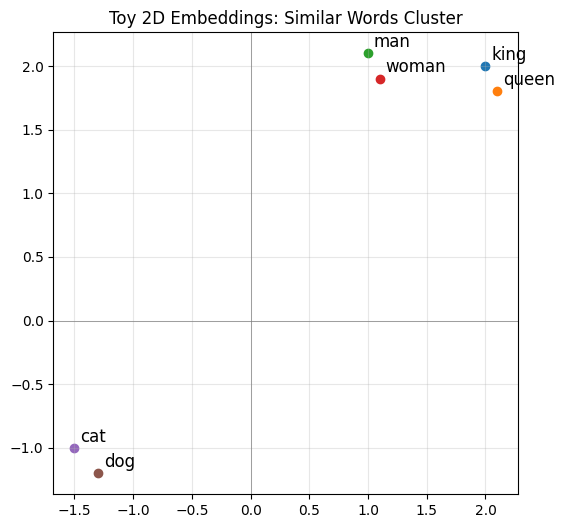

king - man + woman = [2.1 1.8]
queen = [2.1 1.8]
They're close! That's the kind of structure real embeddings learn.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Fake 2D embeddings so we can plot them
vocab = {
    'king': np.array([2.0, 2.0]),
    'queen': np.array([2.1, 1.8]),
    'man': np.array([1.0, 2.1]),
    'woman': np.array([1.1, 1.9]),
    'cat': np.array([-1.5, -1.0]),
    'dog': np.array([-1.3, -1.2]),
}

plt.figure(figsize=(6,6))
for word, vec in vocab.items():
    plt.scatter(vec[0], vec[1])
    plt.text(vec[0]+0.05, vec[1]+0.05, word, fontsize=12)
plt.axhline(0, color='gray', lw=0.5)
plt.axvline(0, color='gray', lw=0.5)
plt.title("Toy 2D Embeddings: Similar Words Cluster")
plt.grid(True, alpha=0.3)
plt.show()

# The famous analogy: king - man + woman â queen
result = vocab['king'] - vocab['man'] + vocab['woman']
print(f"king - man + woman = {result}")
print(f"queen = {vocab['queen']}")
print("They're close! That's the kind of structure real embeddings learn.")

## 3. The Transformer: Attention Is All You Need

Embeddings alone have no context. In 'bank of the river' vs 'bank account', the word 'bank' needs different meanings.

Transformers solve this with **self-attention**. Each token looks at every other token and decides how much to 'pay attention' to it. Then it updates its own representation.

### 3.1 Query, Key, Value
For each token, we create 3 vectors:
- **Query**: What am I looking for?
- **Key**: What do I contain?
- **Value**: What info should I pass along?

Attention score = how well Query matches Key. Then we do a weighted sum of Values.

Here's a minimal self-attention implementation:

In [3]:
def simple_attention(Q, K, V):
    """
    Q, K, V: arrays of shape [seq_len, d_model]
    Returns: output of shape [seq_len, d_model]
    """
    d_k = Q.shape[-1]
    # 1. Compute attention scores: Q @ K^T
    scores = Q @ K.T / np.sqrt(d_k)  # scale to prevent huge values
    
    # 2. Softmax to get weights that sum to 1
    weights = np.exp(scores)
    weights = weights / weights.sum(axis=-1, keepdims=True)
    
    # 3. Weighted sum of Values
    output = weights @ V
    return output, weights

# Example: 3 tokens, 4 dimensions
seq_len, d_model = 3, 4
X = np.random.randn(seq_len, d_model)  # fake embeddings for 3 tokens

# In real models, Q,K,V are linear projections: Q = X @ W_q
# We'll just use X for all three to keep it simple
output, attn_weights = simple_attention(X, X, X)

print("Attention weights - row i shows what token i attends to:")
print(np.round(attn_weights, 2))
print("\nEach row sums to 1.0:", np.round(attn_weights.sum(axis=1), 2))

Attention weights - row i shows what token i attends to:
[[0.51 0.33 0.16]
 [0.13 0.83 0.03]
 [0.04 0.02 0.94]]

Each row sums to 1.0: [1. 1. 1.]


### 3.2 Multi-Head Attention + Feed Forward

Real transformers do this in parallel 8-128 times â **multi-head attention**. Each head can focus on different things: one tracks grammar, another tracks topics, another tracks pronouns.

After attention, each token goes through a **feed-forward network**: basically `ReLU(xW1 + b1)W2 + b2`. This lets it 'think' about what it gathered from attention.

Stack 12-96 of these attention + feedforward blocks and you get GPT-3, LLaMA, etc. Each layer refines the representations.

## 4. Predicting the Next Token

After all transformer layers, each token position has a rich vector that 'understands' context. We take the final vector and project it back to vocabulary size to get logits for every possible next token.

`logits = final_hidden @ W_vocab  # shape: [vocab_size]`

Then `softmax(logits)` gives probabilities. The model is trained so that the correct next token has high probability.

Training objective: **next-token prediction** on trillions of words. That's it. Everything else emerges from that.

## 5. Generation: Sampling from the Model

To generate text, we:
1. Feed prompt â get probabilities for next token
2. Sample one token
3. Append it, feed back in, repeat

How we sample matters a lot. Let's implement the main strategies:

In [4]:
def softmax(x, temperature=1.0):
    x = x / temperature
    e_x = np.exp(x - np.max(x))  # stability
    return e_x / e_x.sum()

def sample_top_k(probs, k=50):
    top_k_idx = np.argsort(probs)[-k:]
    top_k_probs = probs[top_k_idx]
    top_k_probs = top_k_probs / top_k_probs.sum()
    return np.random.choice(top_k_idx, p=top_k_probs)

def sample_top_p(probs, p=0.9):
    sorted_idx = np.argsort(probs)[::-1]
    sorted_probs = probs[sorted_idx]
    cumsum = np.cumsum(sorted_probs)
    cutoff = np.searchsorted(cumsum, p) + 1
    top_p_idx = sorted_idx[:cutoff]
    top_p_probs = probs[top_p_idx]
    top_p_probs = top_p_probs / top_p_probs.sum()
    return np.random.choice(top_p_idx, p=top_p_probs)

# Fake logits for vocab of size 10
logits = np.array([1.0, 2.0, 3.0, 1.5, 0.5, 0.1, 0.2, 0.0, 0.3, 4.0])

print("Raw logits:", np.round(logits, 2))
print("Temp=1.0:", np.round(softmax(logits, 1.0), 2))
print("Temp=0.1:", np.round(softmax(logits, 0.1), 2), "<- more confident")
print("Temp=2.0:", np.round(softmax(logits, 2.0), 2), "<- more random")

probs = softmax(logits, 1.0)
print("\nTop-k=3 sample:", sample_top_k(probs, k=3))
print("Top-p=0.9 sample:", sample_top_p(probs, p=0.9))

Raw logits: [1.  2.  3.  1.5 0.5 0.1 0.2 0.  0.3 4. ]
Temp=1.0: [0.03 0.08 0.21 0.05 0.02 0.01 0.01 0.01 0.01 0.57]
Temp=0.1: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.] <- more confident
Temp=2.0: [0.07 0.11 0.19 0.09 0.05 0.04 0.05 0.04 0.05 0.31] <- more random

Top-k=3 sample: 1
Top-p=0.9 sample: 9


**Temperature**: <1.0 makes it conservative, >1.0 makes it creative/chaotic  
**Top-k**: Only consider k most likely tokens  
**Top-p**: Consider tokens until cumulative prob reaches p

ChatGPT uses something like temp=0.7, top_p=0.95 by default.

## 6. From Next-Token to Chat

Base models just complete text. To make them helpful chatbots, we do 2 more steps:

### 6.1 Instruction Tuning / SFT
Fine-tune on thousands of examples of {instruction, good response}. This teaches the format:
```
User: Explain gravity
Assistant: Gravity is the force that attracts...
```

### 6.2 RLHF - Reinforcement Learning from Human Feedback
1. Generate several responses
2. Humans rank them
3. Train a reward model to predict human preference
4. Use RL to make the LLM generate responses that score high

This is why ChatGPT won't tell you how to build bombs but will write poetry. It's been trained to be helpful, harmless, and honest.

## 7. Key Limitations to Remember

1. **Hallucination**: Models predict plausible text, not true text. They'll invent facts confidently.
2. **Context window**: Can only 'see' last N tokens â 4k to 1M tokens depending on model. Everything earlier is forgotten.
3. **No real-time knowledge**: Training data has a cutoff. I don't know what happened 5 minutes ago unless I search.
4. **Tokenization quirks**: Can't reliably count letters, do math, or reverse strings because it sees tokens, not characters.

Try this: ask an LLM how many 'r's are in 'strawberry'. It often gets it wrong because 'straw' and 'berry' might be separate tokens.

In [5]:
enc = tiktoken.get_encoding("cl100k_base")
print(enc.encode("strawberry"))  # See how it's tokenized
for t in enc.encode("strawberry"):
    print(f"{t} -> '{enc.decode([t])}'")

[496, 675, 15717]
496 -> 'str'
675 -> 'aw'
15717 -> 'berry'


## 8. Putting It All Together

**Training**: Trillions of tokens â predict next token â update billions of weights via backprop

**Inference**: 
```
text â tokens â embeddings â [attention + FFN] x N layers â logits â softmax â sample â next token
                                                                      â
                                                            repeat for each new token
```

That loop + instruction tuning + RLHF = ChatGPT, Claude, Muse, etc.

### Further Reading
- "Attention Is All You Need" - Vaswani et al. 2017, the transformer paper
- "The Illustrated Transformer" by Jay Alammar - amazing visual guide
- Andrej Karpathy's "Let's build GPT" on YouTube - codes GPT from scratch
- Anthropic's "Constitutional AI" paper - how RLHF works

### Exercises
1. Change temperature/top-p values above. How does output randomness change?
2. Try tokenizing weird strings: emojis, code, other languages
3. Implement causal masking: tokens should only attend to previous tokens, not future ones. Hint: set attention scores to -inf

Have fun! You're now dangerous enough to fine-tune your own tiny LLM.